# **Relevance Classification**

### **Team Members**

- Blaise Marvin Rusoke 202354498
- Le Phuong Linh 202385468
- Aravinthkumar Pattaiyan 202367339
- Shrishti Sridhar Manja 202362138
- Hrutuja Mangesh Patkar 202389142

Colab Link: https://drive.google.com/file/d/15202m2RArOPU8xQFRACwctNpMDHPzhJO/view?usp=sharing

## **1.0 Introduction**

This project is aimed at developing a model capable of predicting the relevance of a newspaper article to a user's specific information need, based on the article's content (doc_id, author, body, byline, title) and the user's search query. Utilizing natural language processing (NLP) techniques, the data has been pre-processed, extracting features from the text and transforming them into a suitable format for machine learning models. Following that, various models were explored, including standard Machine Learning Model, 3-Layer neural networks, deep layer neural networks with different configurations and complex neural network models with Long short-term memory (LSTM) and Convolutional Neural Networks (CNN) to predict the relevance of article content to user's information. To identify relevant judgements, F1 score is chosen to measure model performance.

Key findings include, Adjusting the neuron count in the 3-layer NN slightly improved predictions, highlighting model capacity's role.Changing activation functions marginally enhanced performance, emphasizing non-linear transformations' importance.
More neural network layers didn't lead to better outcomes, suggesting potential overfitting or inadequate training.
Exploring different embedding techniques significantly boosted results, showing the value of advanced text representations.
These insights emphasize the balance between model architecture and data representation in NLP tasks for information retrieval.

### **1.1 Data Setup**

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

# Libraries for text preprocessing
from bs4 import BeautifulSoup
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import string
import re

# Download NLTK resources""
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


from scipy.sparse import hstack

# Libraries for vectorization
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import OneHotEncoder

# Libraries for ML
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils import class_weight

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import tensorflow.keras.backend as K
from tensorflow.keras.layers import Lambda
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
import random

import warnings
warnings.simplefilter(action='ignore')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\xvb23162\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\xvb23162\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\xvb23162\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Python pandas library has been uitilised to read the data into memory:

In [ ]:
# Load training data
training_df = pd.read_parquet("relevance_train.parquet")

## **2.0 Methods**

### **2.1 Exploratory Data Analysis**

Exploratory analysis of the training set revealed that the data set is predominantly text features. Additionally, a target class imbalance exists as well, and some ò the features have missing values. The target distribution remains unchanged after treating missing values. The dataset is highly imbalanced; so the accuracy score may be misleading as it gives equal weights to all categories. Thus, F1 Score is employed in this project to evaluate model performance. Moreover, class imbalance is going to be handled in the model training in later parts.

In [ ]:
# Check target distribution
judgement_counts = training_df['judgement'].value_counts()
total = judgement_counts.sum()
percentages = (judgement_counts / total) * 100
print(percentages)

judgement
0    84.284847
1    15.715153
Name: count, dtype: float64


In [ ]:
# visualization of the first 5 records
training_df.head()

,doc_id,judgement,author,body,byline,title,topic_id,description,narrative,topic_title
0,004c6120d0aa69da29cc045da0562168,0,Terrence McCoy,"<p>More than 60 years ago, a fair-skinned Iris...",By Terrence McCoy,Report on Irish baby homes documents use of in...,321,Pertinent documents will reflect the fact that...,Pertinent documents relating to this issue wil...,Women in Parliaments
1,005a1f0c2064487a7f15443b2a5f349a,0,Brian McNoldy,"<p>Hurricane Fred, which formed over the weeke...",By Brian McNoldy,Hurricane Fred is a fountain of ‘firsts’ in th...,321,Pertinent documents will reflect the fact that...,Pertinent documents relating to this issue wil...,Women in Parliaments
2,00722094-2935-11e2-b4e0-346287b7e56c,0,Editorial Board,"<p>EIGHT YEARS AGO this month, an inspiring mo...",By Editorial Board,Ukraine slides away from democracy,321,Pertinent documents will reflect the fact that...,Pertinent documents relating to this issue wil...,Women in Parliaments
3,007d2856-7cc4-11e4-84d4-7c896b90abdc,0,Adam Bernstein,"<p>Mary Burke Washington, an economist who was...",By Adam Bernstein,"Mary Washington, government official and widow...",321,Pertinent documents will reflect the fact that...,Pertinent documents relating to this issue wil...,Women in Parliaments
4,009aafb6-0283-11e6-8bb1-f124a43f84dc,0,None,"<p>When Treasury Secretary Jack Lew <a href=""h...",None,Will women be shortchanged again?,321,Pertinent documents will reflect the fact that...,Pertinent documents relating to this issue wil...,Women in Parliaments


Visualizing the title, body, description and topic title features for the first record:

In [ ]:
# description is a representation of what the user was actually searching for
training_df['description'][0]

'Pertinent documents will reflect the fact that women continue to be poorly represented in parliaments across the world, and the gap in political power between the sexes is very wide, particularly in the Third World.'

In [ ]:
# topic title is a representation of what the user was actually searching for
training_df['topic_title'][0]

'Women in Parliaments'

In [ ]:
# title is a representation of the actual contents of the article
training_df['title'][0]

'Report on Irish baby homes documents use of infants for med school cadavers, vaccine testing'

The visualization demonstrates the accuracy of title and body for newspaper articles and description and narrative for user queries. A subset with these features is created for training the machine learning model.

In [ ]:
# create a copy of the original dataset
training_df2 = training_df.copy()

In [ ]:
# extract the useful representative features
training_df2 = training_df2.reindex(columns=['judgement','body','description','title','topic_title'])

### **2.2. Text preprocessing**

In the preprocessing phase of our study, we aimed at refining the dataset for optimal analysis, null values in the features were addressed by being substituted with empty strings. Since the features will be combined at a later stage, elimination the null values at in individual feature columns.

HTML elements such as links and tags were removed using BeautifulSoup, to prevent skewing of text analysis. The text was then normalized to lowercase and cleansed of non-alphanumeric characters using regular expressions, preparing it for further processing. The text was broken down into words through tokenization, followed by the removal of punctuation and stopwords—words that are common in English but carry minimal semantic weight. This refinement process was crucial for focusing on meaningful content.

Additionally, the columns ['body', 'description', 'title', 'topic_title'] were combined as a single column. Later on  Tf-idf encoding is performed to transform text into numerical data, thereby enabling machine learning models to be facilitated in understanding and processing textual information. This thorough preprocessing pipeline was essential not only for cleaning the data but also for addressing the challenges posed by the imbalance in the training data (85% non-relevant, 15% relevant).

In [ ]:
training_df2.isna().sum()

judgement       0
body           69
description     0
title           0
topic_title     0
dtype: int64

In [ ]:
# replace the null values with empty text
training_df2.fillna(' ',inplace=True)

The mathematical computations used by machine learning algorithms can not handle null values. We therefore searched the dataset for these values and replaced them with empty text.

In [ ]:
# Preprocessing function
def preprocess_text(text):
  # remove html links, anchor tags and paragraph tags
  soup = BeautifulSoup(text,'html.parser')
  text = soup.get_text()

  text = text.lower()
  # remove unncessary backslashes
  text = re.sub(r'[^\w\s()/\\]', ' ',text)

  # remove unnecessary next line string tags
  text = text.replace('\\n', '')

  # the text has a consistent 'xa0' string - remove it too
  text = text.replace('\xa0', ' ')

  # tokenize - remove punctuations - remove stopwords - lemmatize
  tokens = word_tokenize(text)

  # remove punctuations
  tokens = [word for word in tokens if word not in string.punctuation]

  # Remove stop words
  stop_words = set(stopwords.words('english'))
  tokens = [word for word in tokens if word.lower() not in stop_words]

  lemmatizer = WordNetLemmatizer()
  tokens = [lemmatizer.lemmatize(word) for word in tokens]

  sentence = ' '.join(tokens)

  return sentence

Apply preprocessing function for all the features except target

In [ ]:
training_df2['body'] = training_df2['body'].apply(preprocess_text)

In [ ]:
training_df2['description'] = training_df2['description'].apply(preprocess_text)

In [ ]:
training_df2['title'] = training_df2['title'].apply(preprocess_text)

In [ ]:
training_df2['topic_title'] = training_df2['topic_title'].apply(preprocess_text)

Below is a visualization of some of the clean text in the preprocessed columns

In [ ]:
training_df2['description'][0]

'pertinent document reflect fact woman continue poorly represented parliament across world gap political power sex wide particularly third world'

In [ ]:
training_df2['title'][0]

'report irish baby home document use infant med school cadaver vaccine testing'

In [ ]:
training_df2['topic_title'][0]

'woman parliament'

In [ ]:
df_combine = training_df2.copy()

In [ ]:
# Combine text used for training model
df_combine['combined_text'] = df_combine['body'] + ' ' + df_combine['description'] + ' ' + df_combine['title'] + ' ' + df_combine['topic_title']
df_combine.drop(['body','description','title','topic_title'],axis=1,inplace=True)

### **2.3 Test Train Split**

In order to ensure a stratified distribution of classes and maintain proportionate representation across splits, our data split strategy involves splitting the dataset into training, validation, and test sets. Using a random seed for reproducibility and stratification to maintain class balance, we partioned the dataset into training, validation and test splits of 97%, 1.5% and 1.5% respectively.

In [ ]:
# Split texts and labels for train data
train_text_full, valid_text, train_label_full, valid_label = train_test_split(df_combine.drop('judgement', axis =1),
                                                                    df_combine['judgement'], # target
                                                                    test_size = 0.015,
                                                                    random_state = 42,
                                                                    shuffle = True,
                                                                    stratify = df_combine['judgement'])

In [ ]:
train_text, test_text, train_label, test_label = train_test_split(train_text_full,
                                                                    train_label_full,
                                                                    test_size = 0.015,
                                                                    random_state = 42,
                                                                    shuffle = True,
                                                                    stratify = train_label_full)

In [ ]:
train_text.reset_index(drop = True, inplace = True)
valid_text.reset_index(drop = True, inplace = True)
train_label.reset_index(drop = True, inplace = True)
valid_label.reset_index(drop = True, inplace = True)
test_text.reset_index(drop = True, inplace = True)
test_label.reset_index(drop = True, inplace = True)

### **2.4 Tf-Idf Encoding**

In order to ensure a stratified distribution of classes and maintain proportionate representation across splits, our data split strategy involves splitting the dataset into training, validation, and test sets. Using a random seed for reproducibility and stratification to maintain class balance, we partioned the dataset into training, validation and test splits of 97%, 1.5% and 1.5% respectively.

In [ ]:
# Range (inclusive) of n-gram sizes for tokenizing text.
NGRAM_RANGE = (1, 2)

# Limit on the number of features. We use the top 20K features.
TOP_K = 20000

# Whether text should be split into word or character n-grams.
# One of 'word', 'char'.
TOKEN_MODE = 'word'

# Minimum document/corpus frequency below which a token will be discarded.
MIN_DOCUMENT_FREQUENCY = 2

def ngram_vectorize(train_texts, train_labels, val_texts):
     # Create keyword arguments to pass to the 'tf-idf' vectorizer.
    kwargs = {
            'ngram_range': NGRAM_RANGE,  # Use 1-grams + 2-grams.
            'dtype': 'int32',
            'strip_accents': 'unicode',
            'decode_error': 'replace',
            'analyzer': TOKEN_MODE,  # Split text into word tokens.
            'min_df': MIN_DOCUMENT_FREQUENCY,
    }
    vectorizer = TfidfVectorizer(**kwargs)

    # Learn vocabulary from training texts and vectorize training texts.
    x_train = vectorizer.fit_transform(train_texts)

    # Vectorize validation texts.
    x_val = vectorizer.transform(val_texts)

    # Select top 'k' of the vectorized features.
    selector = SelectKBest(f_classif, k=min(TOP_K, x_train.shape[1]))
    selector.fit(x_train, train_labels)
    x_train = selector.transform(x_train).astype('float32')
    x_val = selector.transform(x_val).astype('float32')
    return x_train, x_val

X_train, X_valid = ngram_vectorize(train_text['combined_text'], train_label, valid_text['combined_text'])
X_train, X_test = ngram_vectorize(train_text['combined_text'], train_label, test_text['combined_text'])

## **3.0 Models**
Because of the significant class imbalance, for all models, we utilize the F1 score as our target metric - since this is the metric that maximizes both precision and recall and will provide an accurate representation of the true performance of the models.

### **3.1 Baseline Machine Learning Models**

In our comprehensive model evaluation and hyperparameter tuning process, several machine learning algorithms were explored, including Multinomial Naive Bayes, Logistic Regression, Support Vector Machine (SVM), Random Forest, and XGBoost, to identify the most effective model for the text classification task. Specific hyperparameters were meticulously tuned for each model: learning_rate, n_estimators, and max_depth for XGBoost; alpha, C, and kernel for SVM; and n_estimators and max_depth for Random Forest.

**3.1.1 Naive Bayes**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Set hyperparameters
alpha_values = [0.1, 1.0, 10.0]  # Laplace smoothing parameter
best_nb_f1 = 0
nb_recall = 0
nb_precision = 0
best_alpha = None

for alpha in alpha_values:
    model = MultinomialNB(alpha=alpha)
    model.fit(X_train, train_label)
    y_pred = model.predict(X_valid)
    precision = precision_score(valid_label,y_pred)
    recall = recall_score(valid_label, y_pred)
    f1 = f1_score(valid_label, y_pred)

    if  f1 > best_nb_f1:
        best_nb_f1 = f1
        best_alpha = alpha
        nb_recall = recall
        nb_precision = precision

# Train Final Model with Best Hyperparameters
best_nb = MultinomialNB(alpha=best_alpha)
best_nb.fit(X_train, train_label)

# Evaluate Model on Test Set
y_test_pred = best_nb.predict(X_test)

# Print results
print(f"Alpha: {best_alpha}")
print("Valid Set Performance:")
print(classification_report(test_label, y_test_pred))

Alpha: 0.1
Valid Set Performance:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       246
           1       0.90      0.20      0.32        46

    accuracy                           0.87       292
   macro avg       0.88      0.60      0.62       292
weighted avg       0.87      0.87      0.83       292



**3.1.2 Logistic Regression**

In [ ]:
# Set hyperparameters
hyperparameters = {'C': [0.1, 1, 10]}
best_log_f1 = 0
log_precision = 0
log_recall = 0
best_params = {}

for C in hyperparameters['C']:
    model = LogisticRegression(C=C, penalty='l2', class_weight = 'balanced', random_state = 42, max_iter=1000)
    model.fit(X_train, train_label)
    y_pred = model.predict(X_valid)
    precision = precision_score(valid_label,y_pred)
    recall = recall_score(valid_label, y_pred)
    f1 = f1_score(valid_label, y_pred)

    if f1 > best_log_f1:
      best_log_f1 = f1
      best_params['C'] = C
      log_recall = recall
      log_precision = precision

# Train Final Model with Best Hyperparameters
best_log = LogisticRegression(C=best_params['C'], penalty='l2', class_weight = 'balanced', max_iter=1000, random_state = 42)
best_log.fit(X_train, train_label)

# Predict results
y_test_pred = best_log.predict(X_test)

# Print results
print(f"C: {C}")
print("Valid Set Performance:")
print(classification_report(test_label, y_test_pred))

C: 10
Valid Set Performance:
              precision    recall  f1-score   support

           0       0.96      0.83      0.89       246
           1       0.48      0.83      0.61        46

    accuracy                           0.83       292
   macro avg       0.72      0.83      0.75       292
weighted avg       0.89      0.83      0.85       292



**3.1.3 Support Vector Machine**


In [ ]:
# Set hyperparameters
hyperparameters = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
best_svm_f1 = 0
svm_precision = 0
svm_recall = 0
best_params = {}

for C in hyperparameters['C']:
    for kernel in hyperparameters['kernel']:
        model = SVC(C=C, kernel=kernel, random_state = 42, class_weight='balanced', max_iter = 1000)
        model.fit(X_train, train_label)
        y_pred = model.predict(X_valid)
        precision = precision_score(valid_label,y_pred)
        recall = recall_score(valid_label, y_pred)
        f1 = f1_score(valid_label, y_pred)

        if f1 > best_svm_f1:
            best_svm_f1 = f1
            svm_precision = precision
            svm_recall = recall
            best_params['C'] = C
            best_params['kernel'] = kernel

# Train Final Model with Best Hyperparameters
best_svm = SVC(C=best_params['C'], kernel = best_params['kernel'], max_iter=1000, class_weight='balanced', random_state = 42)
best_svm.fit(X_train, train_label)

# Predict results
y_test_pred = best_svm.predict(X_test)

# Print results
print(f"C: {C}, Kernel: {kernel}")
print("Valid Set Performance:")
print(classification_report(test_label, y_test_pred))

C: 10, Kernel: rbf
Valid Set Performance:
              precision    recall  f1-score   support

           0       0.88      0.89      0.89       246
           1       0.39      0.37      0.38        46

    accuracy                           0.81       292
   macro avg       0.63      0.63      0.63       292
weighted avg       0.80      0.81      0.81       292



**3.1.4 Random Forest**

In [ ]:
# Set hyperparameters
hyperparameters = {'n_estimators': [100, 200, 300], 'max_depth': [None, 5, 10, 20]}
best_rf_f1 = 0
rf_precision = 0
rf_recall = 0
best_params = {}

for n_estimators in hyperparameters['n_estimators']:
    for max_depth in hyperparameters['max_depth']:
        model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, class_weight = 'balanced', random_state=42)
        model.fit(X_train, train_label)
        y_pred = model.predict(X_valid)
        precision = precision_score(valid_label,y_pred)
        recall = recall_score(valid_label, y_pred)
        f1 = f1_score(valid_label, y_pred)

        if f1 > best_rf_f1:
            best_rf_f1 = f1
            rf_precision = precision
            rf_recall = recall
            best_params['n_estimators'] = n_estimators
            best_params['max_depth'] = max_depth

# Train Final Model with Best Hyperparameters
best_rf = RandomForestClassifier(n_estimators=best_params['n_estimators'], max_depth=best_params['max_depth'], class_weight = 'balanced', random_state=42)
best_rf.fit(X_train, train_label)

# Predict results
y_test_pred = best_rf.predict(X_test)

# Print results
print(f"n_estimators: {n_estimators}, max_depth: {max_depth}")
print("Valid Set Performance:")
print(classification_report(test_label, y_test_pred))

n_estimators: 300, max_depth: 20
Valid Set Performance:
              precision    recall  f1-score   support

           0       0.92      0.95      0.93       246
           1       0.67      0.57      0.61        46

    accuracy                           0.89       292
   macro avg       0.79      0.76      0.77       292
weighted avg       0.88      0.89      0.88       292



**3.1.5 XGBoost**


In [ ]:
# Define Parameter Grid
params_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200, 300],
}

best_xgb_f1 = 0
xgb_precision = 0
xgb_recall = 0
best_params = {}

# Train and Evaluate
for learning_rate in params_grid['learning_rate']:
    for max_depth in params_grid['max_depth']:
        for n_estimators in params_grid['n_estimators']:
            # Initialize XGBoost model with current hyperparameters
            model = xgb.XGBClassifier(learning_rate=learning_rate, max_depth=max_depth, n_estimators=n_estimators)
            model.fit(X_train, train_label)
            y_pred = model.predict(X_valid)
            precision = precision_score(valid_label,y_pred)
            recall = recall_score(valid_label, y_pred)
            f1 = f1_score(valid_label, y_pred)

            # Check if current model is the best so far
            if f1 > best_xgb_f1:
                best_xgb_f1 = f1
                xgb_precision = precision
                xgb_recall = recall
                best_params = {'learning_rate': learning_rate, 'max_depth': max_depth, 'n_estimators': n_estimators}

# Train Final Model with Best Hyperparameters
best_xgb = xgb.XGBClassifier(n_estimators=best_params['n_estimators'], max_depth=best_params['max_depth'], learning_rate= best_params['learning_rate'], random_state=42)
best_xgb.fit(X_train, train_label)

# Predict results
y_test_pred = best_xgb.predict(X_test)

# Print results
print(f"n_estimators: {n_estimators}, max_depth: {max_depth}, learning_rate: {learning_rate}")
print("Valid Set Performance:")
print(classification_report(test_label, y_test_pred))

n_estimators: 300, max_depth: 7, learning_rate: 0.1
Valid Set Performance:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       246
           1       0.73      0.35      0.47        46

    accuracy                           0.88       292
   macro avg       0.81      0.66      0.70       292
weighted avg       0.86      0.88      0.86       292



### **3.2 Three Layer Neural Networks Baseline Model**

3-layer neural network model (including 1 input layer, 1 hidden layer, and 1 output layer) was built and optimised by fine-tuning the hidden layer's neuron count. To tackle the issue of class imbalance, class weights were calculated and incorporated during the training process. Various neuron counts—8, 16, 32, 64, 128, 256, and 512—were explored to determine their impact on model performance, with F1 score on the validation set serving as the criterion for assessment. The models were configured to train using a binary cross-entropy loss function, with 'adam' as the optimizer and F1 score as the metric of performance.

Informative features about the article and the user's query terms are considered for relevance judgement. Specifically, the body and title features are used as representations of the article, and the topic_title and description features are utilized as representations of the user's query. The user's query terms and the article's informative features were taken into account when determining relevance. The article was specifically represented by the body and title features, and the user's query was represented by the topic_title and description features.

In [ ]:
from sklearn.utils import compute_class_weight
class_labels = np.unique(train_label)
class_weights = compute_class_weight(class_weight = 'balanced',classes = class_labels, y = train_label)
class_weight_dict = dict(zip(class_labels, class_weights))

In [ ]:
def shallowNN(num_neurons=64, activation='relu', optimizer='adam'):
    NN_baseline = keras.models.Sequential([
              keras.layers.Dense(num_neurons, activation = activation, input_shape = X_train.shape[1:]),
              keras.layers.Dense(1, activation = 'sigmoid')])
    NN_baseline.compile(loss="binary_crossentropy",
                  optimizer= optimizer,
                  metrics=["f1_score"]
                 )
    return NN_baseline

In [ ]:
X_train = X_train.toarray()
X_valid = X_valid.toarray()
X_test = X_test.toarray()

In order to ensure results reproducibility, we set the random seeds for numpy, tensorflow and the python random package to a constant value of 42 for each model training.

In [ ]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
from sklearn.metrics import precision_score, recall_score, f1_score
# Set hyperparameters for fine-tuning
num_neurons = [8,16,32,64,128,256,512]


best_f1 = 0
f1_list = []
precision_list = []
recall_list =[]
best_params = {}
results_shallowNN = []

for neurons in num_neurons:
    model = shallowNN(neurons)
    history = model.fit(X_train,train_label,epochs=5,batch_size=16,verbose=0,validation_data=(X_valid, valid_label),class_weight=class_weight_dict)
    y_proba_shallowNN = model.predict(X_valid)
    y_pred_shallowNN = (y_proba_shallowNN>0.5).astype('int32')
    precision = precision_score(valid_label,y_pred_shallowNN)
    recall = recall_score(valid_label, y_pred_shallowNN)
    f1 = f1_score(valid_label, y_pred_shallowNN)

    f1_list.append(f1)
    precision_list.append(precision)
    recall_list.append(recall)

    if f1 > best_f1:
        best_f1 = f1
        best_params = {'num_neurons':neurons}

    results_shallowNN.append({
            'Number of Neurons': neurons,
            'Precision': precision,
            'Recall': recall,
            'F1 Score': f1
        })

print("Best F1 score:", best_f1)
print("Best Parameters:", best_params)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Best F1 score: 0.6050420168067226
Best Parameters: {'num_neurons': 64}


In [ ]:
# Check result of the best model
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
best_shallowNN = shallowNN(512)

best_shallowNN.fit(X_train,train_label,epochs=5,batch_size=16,verbose=0,validation_data=(X_valid, valid_label), class_weight = class_weight_dict)
y_proba_bestshallow = best_shallowNN.predict(X_test)
y_pred_bestshallow = (y_proba_bestshallow>0.5).astype('int32')

print(classification_report(test_label, y_pred_bestshallow))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       246
           1       0.56      0.61      0.58        46

    accuracy                           0.86       292
   macro avg       0.74      0.76      0.75       292
weighted avg       0.87      0.86      0.87       292



### **3.2 Deep Neural Networks Model**

The conducted experiment aimed to create and optimize a deep neural network (DNN) for binary classification tasks, inheriting settings from a previously built 3-layer model without modifications. It evaluated the impact of different activation functions—ReLU, eLU, SeLU, GeLU, Swish, Mish, and LeakyReLU—and the number of layers (4 to 8) on performance, focusing on precision, recall, and F1 score. This focus is due to the varying properties of activation functions, which affect learning dynamics and model's ability to learn complex patterns, and the number of layers, which impacts the model’s capacity and potential overfitting. The optimization seeks to improve classification while managing false positives and negatives, essential in class imbalance scenarios.

In [ ]:
from tensorflow.keras.layers import Dense, BatchNormalization, LeakyReLU
from tensorflow.keras.activations import relu, elu, selu, swish, mish, gelu

# Define activation functions
leaky_relu = LeakyReLU(alpha=0.2)
activations = ['relu','elu','selu','gelu','swish','mish',leaky_relu]

# Define number of layers configurations
layers = range(4,9)

# Initialize dictionaries to store results
precision_scores = {activation_name: [] for activation_name in activations}
recall_scores = {activation_name: [] for activation_name in activations}
f1_scores = {activation_name: [] for activation_name in activations}

In [ ]:
def deepNN(layers, units = 64, activation = 'relu', kernel_initializer='he_normal'):
    model = keras.models.Sequential()
    model.add(keras.layers.Input(shape = X_train.shape[1:]))
    for i in range(layers-2):
        model.add(keras.layers.Dense(units=units, activation=activation, kernel_initializer=kernel_initializer,kernel_regularizer = keras.regularizers.l2()))
        model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.Dense(units=1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy',optimizer=keras.optimizers.Adam(learning_rate=1e-3), metrics = ['f1_score'])
    return model

In [ ]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

best_deep_f1 = 0
best_params = {'activation': None, 'layers': None}
results_deepNN = []

from sklearn.metrics import f1_score,recall_score
for activation_name in activations:
    for layer in layers:
        if activation_name == 'selu':
            model = deepNN(layer, activation = activation_name, kernel_initializer = 'lecun_normal')
        else:
            model = deepNN(layer, activation = activation_name)

        history = model.fit(X_train,train_label,verbose=0,epochs=5,batch_size=16, validation_data=(X_valid,valid_label), class_weight = class_weight_dict)
        y_pred = (model.predict(X_valid) > 0.5).astype('int32')
        precision = precision_score(valid_label, y_pred)
        recall = recall_score(valid_label, y_pred)
        f1 = f1_score(valid_label, y_pred)

        precision_scores[activation_name].append(precision)
        recall_scores[activation_name].append(recall)
        f1_scores[activation_name].append(f1)

        if f1 >  best_deep_f1:
            best_deep_f1 = f1
            best_params['activation'] = activation_name
            best_params['layers'] = layer

        results_deepNN.append({
            'Activation': activation_name,
            'Number of Layers': layer,
            'Precision': precision,
            'Recall': recall,
            'F1 Score': f1
        })

print(best_params)
print(best_deep_f1)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
10/10 

In [ ]:
# Check result of the best model
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

best_deepNN = deepNN(layers = 6, activation = 'swish')
best_deepNN.fit(X_train,train_label,epochs=5,batch_size=16,verbose=0,validation_data=(X_valid, valid_label), class_weight = class_weight_dict)
y_proba_bestdeep = best_deepNN.predict(X_test)
y_pred_bestdeep = (y_proba_bestdeep>0.5).astype('int32')

print(classification_report(test_label, y_pred_bestdeep))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       246
           1       0.81      0.28      0.42        46

    accuracy                           0.88       292
   macro avg       0.85      0.64      0.68       292
weighted avg       0.87      0.88      0.85       292



### **3.3 Data preprocessing for complex models**

#### 3.3.1 Shuffling and Categorising

The dataset preprocessing involved shuffling and organising into two distinct categories: articles and queries.

In [ ]:
training_df2 = shuffle(training_df2)

In [ ]:
training_df2

,judgement,body,description,title,topic_title
18999,0,thursday march 13digital mammogram low income ...,link toxic chemical exposure diabetes,prince george county community calendar march ...,diabetes toxic chemical
23890,0,young child come cold congestion scratchy sore...,identify document specify mortality rate speci...,child bad cold feel awful bother cold med,bacterial infection mortality rate
22265,0,president obama announced wednesday u would se...,find detail prisoner exchange cuba u released ...,cuban american cuba lost cuba could,alan gross released cuba
13993,0,engineering technology among challenging field...,find document describe advantage hiring potent...,want college pay 50 major highest earnings,college education advantage
9246,0,aarp northern virginia tax aide need volunteer...,provide information use dog worldwide law enfo...,loudoun county volunteer opportunity,law enforcement dog
...,...,...,...,...,...
14348,0,australia15 arrested major anti terror operati...,find document describe religious objection pol...,world digest sept 17 2014,africa polio vaccination
15105,1,vice president biden attack dog mode thursday ...,identify reason decline middle class u,biden attack dog mode iowa take aim romney ryan,declining middle class u
6562,0,thursday samsung finally took step officially ...,identify document discus reason automobile recall,anyone bought galaxy note 7 need know,automobile recall
860,0,even dartmouth president philip j hanlon deliv...,relevant document would discus frequency vicio...,dartmouth battle hard partying reputation pop ...,black bear attack


We then combine all the information about the newspaper article into one column called article - and all the information about a user's query into one column called query.

In [ ]:
training_df2['article'] = training_df2['title'] + ' ' +training_df2['body']
training_df2['query'] = training_df2['topic_title'] + ' '+training_df2['description']

training_df2 = training_df2.reindex(columns=['judgement','article','query'])

Training, validation and test sets are created

In [ ]:
X,Y = training_df2[['article','query']],training_df2['judgement']

In [ ]:
x_train_full,x_valid,y_train_full,y_valid = train_test_split(X,Y,test_size=0.015,random_state=42,stratify=Y)

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x_train_full,y_train_full,test_size=0.015,random_state=42,stratify=y_train_full)

In [ ]:
y_train_ = y_train.values
y_valid_ = y_valid.values
y_test_ = y_test.values

In [ ]:
# visualize the shape of the training, validation and test sets
x_train.shape,x_valid.shape,x_test.shape

((19169, 2), (297, 2), (292, 2))

#### 3.3.2 Tokenisation and Vectorisation

The data set was then tokenised and vectorised using Keras' TextVectorisation layer, a choice motivated by its direct integration into neural network architectures, thereby streamlining the model preparation process and eliminating the need for external preprocessing steps. Given that machine learning models necessitate numerical input formats, the process transformed text strings into integer tokens.

The vocabulary was confined to the top 1,000 words, with sequence lengths limited to 500 tokens, parameters identified as optimal through iterative testing. To suit the model's objective of comparing user queries against documents, two separate text vectorisation layers were deployed for articles and queries respectively.

This preprocessing approach, designed for complex neural network models, diverges from the techniques used in simpler baseline models, such as the 3-layer and deep neural network models, highlighting the sophisticated requirements of advanced model architectures.

In [ ]:
text_vec_layer_articles = tf.keras.layers.TextVectorization(max_tokens=1000,output_sequence_length=500)
text_vec_layer_queries = tf.keras.layers.TextVectorization(max_tokens=1000,output_sequence_length=500)

Partition training data - into a part about the newspaper article and a part about the user query.

In [ ]:
x_train_articles = list(x_train['article'].values)

Fit our text vectorisation layers on the training set

In [ ]:
text_vec_layer_articles.adapt(x_train_articles)

In [ ]:
x_train_queries = list(x_train['query'].values)

In [ ]:
text_vec_layer_queries.adapt(x_train_queries)

In [ ]:
x_valid_queries = list(x_valid['query'].values)
x_valid_articles = list(x_valid['article'].values)
x_test_queries = list(x_test['query'].values)
x_test_articles = list(x_test['article'].values)

Stanford's pretrained GloVe embeddings - downloaded from the official site: https://nlp.stanford.edu/projects/glove/

Each word in our vocabulary is mapped to its representative integer index assigned to it by the tokeniser.

In [ ]:
articles_vocabulary = text_vec_layer_articles.get_vocabulary()
articles_wordindex = {word:index for index,word in enumerate(articles_vocabulary)}

In [ ]:
queries_vocabulary = text_vec_layer_queries.get_vocabulary()
queries_wordindex = {word:index for index,word in enumerate(queries_vocabulary)}

Pretrained embeddings are loaded and then each word in our vocabulary are mapped to its embedding, then each word index from the tokeniser to its representative embedding. 100-dimensional GloVe embeddings were used.

In [ ]:
# load pretrained embeddings into memory
embeddings_index = dict()

In [ ]:
with open('glove.6B.100d.txt', 'r',encoding="utf8") as file:
    for line in file:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:],dtype=np.float32)
        embeddings_index[word] = coefs

Mapping each tokenizer index integer to an embeddings vector. This ensures good starting weights being created for the 2 embedding layers - one embedding layer for the article content and one for the user queries content

In [ ]:
articles_vocab_size = len(articles_wordindex)
articles_embedding_matrix = np.zeros((articles_vocab_size,100))

for word,i in articles_wordindex.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        articles_embedding_matrix[i] = embedding_vector

In [ ]:
queries_vocab_size = len(queries_wordindex)
queries_embedding_matrix = np.zeros((queries_vocab_size,100))

for word,i in queries_wordindex.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        queries_embedding_matrix[i] = embedding_vector

Inspecting the shape of our weights vectors:

In [ ]:
queries_embedding_matrix.shape,articles_embedding_matrix.shape

((300, 100), (1000, 100))

### **3.4 Complex Neural Network Models**

Our approach here makes use of an LSTM model (whose performance was varied with by switching the LSTM with GRUs and bidirectional LSTMs to investigate performance). We also utilized a WaveNet like based CNN architecure.For all our complex models, we utilize a Siamese based approach where by we process the queries and document text features separately. We have one embedding layer to process the features related to the user queries and another embedding layer to process the features related to the document. We then compute the euclidean distance between the 2 sets of embeddings from the embedding layers. The main idea behind this technique was such that our trained model is able to judge whether a user query is relevant to a document - based on the distance between their embeddings.

#### 3.4.1 Long Short Term Memory Model

Complex neural network models were designed to assess the relevance between newspaper articles and user queries. To capture the semantic richness of the text, we employed two separate embedding layers utilizing pretrained GloVe embeddings, allowing us to map each tokenized word to a dense vector representation.

The core of our model architecture involved calculating the Euclidean distance between article and query embeddings, followed by processing through LSTM layers to capture temporal dependencies and nuances in the text. A sigmoid-activated dense layer concluded the model, classifying the relevance of articles to queries.

The experiment further extended to evaluating variations of the base model, incorporating bidirectional LSTM cells to capture context more effectively in both directions and experimenting with GRU cells as an alternative to capture dependencies with potentially less complexity. Additionally, a CNN-based approach was tested to understand spatial relationships within the text embeddings.

Function to compute the Euclidean distance between the 2 sets of embeddings for our Siamese based approach.

In [ ]:
# define a function to compute the Euclidean distance
def euclidean_distance(vectors):
	# unpack the vectors into separate lists
	(featsA, featsB) = vectors
	# compute the sum of squared distances between the vectors
	sumSquared = K.sum(K.square(featsA - featsB), axis=1,
		keepdims=True)
	# return the euclidean distance between the vectors
	return K.sqrt(K.maximum(sumSquared, K.epsilon()))

Code for our Siamese based LSTM model:

In [ ]:
# define our 2 model inputs - article text and user query text
articles_input = tf.keras.layers.Input(shape=(),dtype=tf.string)
queries_input = tf.keras.layers.Input(shape=(),dtype=tf.string)

# tokenize and vectorize using the text vectorization layer
article_tokens = text_vec_layer_articles(articles_input)
query_tokens = text_vec_layer_queries(queries_input)

# compute embeddings using GloVe embeddings.
# set trainable to True to finetune the glove embeddings
articles_embedded = tf.keras.layers.Embedding(input_dim=articles_vocab_size,output_dim=100,
                             embeddings_initializer=tf.keras.initializers.Constant(articles_embedding_matrix),trainable=True,mask_zero=True)(article_tokens)
queries_embedded = tf.keras.layers.Embedding(input_dim=queries_vocab_size,output_dim=100,
                                       embeddings_initializer=tf.keras.initializers.Constant(queries_embedding_matrix),trainable=True,mask_zero=True)(query_tokens)

# compute the Euclidean distance between the 2 embedding vectors
distance=Lambda(euclidean_distance)([articles_embedded,queries_embedded])

# learn the relationship in the data using lstm cells
lstm1 = tf.keras.layers.LSTM(128,return_sequences=True,dropout=0.6)(distance)
lstm2 = tf.keras.layers.LSTM(64,dropout=0.4)(lstm1)

# add a single output layer
out_lstm = tf.keras.layers.Dense(1,activation="sigmoid")(lstm2)

model_lstm = tf.keras.Model(inputs=[articles_input,queries_input],outputs=[out_lstm])

In [ ]:
model_lstm.summary()

Model: "functional_333"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_44      │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_45      │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 500)       │          0 │ input_layer_44[0… │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization… │ (None, 500)       │          0 │ input_layer_45[0… │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 500, 100)  │    100,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 500, 100)  │     30,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 500)       │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 500)       │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 1, 100)    │          0 │ embedding[0][0],  │
│                     │                   │            │ embedding_1[0][0… │
│                     │                   │            │ not_equal[0][0],  │
│                     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 1, 128)    │    117,248 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     49,408 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_196 (Dense)   │ (None, 1)         │         65 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 296,721 (1.13 MB)

 Trainable params: 296,721 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

Convert the input data to appropriate tensorflow inputs:

In [ ]:
x_train_articles = tf.constant(x_train_articles,dtype=tf.string)
x_train_queries = tf.constant(x_train_queries,dtype=tf.string)
x_valid_articles = tf.constant(x_valid_articles,dtype=tf.string)
x_valid_queries = tf.constant(x_valid_queries,dtype=tf.string)
x_test_queries = tf.constant(x_test_queries,dtype=tf.string)
x_test_articles = tf.constant(x_test_articles,dtype=tf.string)

In [ ]:
type(x_train_articles)

tensorflow.python.framework.ops.EagerTensor

In [ ]:
precision = tf.keras.metrics.Precision(name='precison')
f1 = tf.keras.metrics.F1Score(name='f1')

In [ ]:
# the early stopping callback to stop training if the validation loss doesn't improve
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=10, restore_best_weights=True)
# the reduce learning rate on plateau callback to lower the learning rate once it 'plateaus' i.e. is not improving
lrp_reducer = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=6, verbose=1)

In [ ]:
opt = tf.keras.optimizers.Adam(learning_rate=0.001)
model_lstm.compile(loss='binary_crossentropy',optimizer=opt,
              metrics=['accuracy',precision])

In [ ]:
history_lstm = model_lstm.fit((x_train_articles,x_train_queries),y_train_,validation_data=((x_valid_articles,x_valid_queries),y_valid_),
                    epochs=60,batch_size=256,callbacks=[early_stopping,lrp_reducer])

Epoch 1/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step - accuracy: 0.8205 - loss: 0.5022 - precison: 0.1860 - val_accuracy: 0.8418 - val_loss: 0.4282 - val_precison: 0.0000e+00
Epoch 2/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.8397 - loss: 0.4420 - precison: 0.0000e+00 - val_accuracy: 0.8418 - val_loss: 0.4279 - val_precison: 0.0000e+00
Epoch 3/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.8397 - loss: 0.4405 - precison: 0.0000e+00 - val_accuracy: 0.8418 - val_loss: 0.4279 - val_precison: 0.0000e+00
Epoch 4/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.8397 - loss: 0.4404 - precison: 0.0000e+00 - val_accuracy: 0.8418 - val_loss: 0.4284 - val_precison: 0.0000e+00
Epoch 5/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.8397 - loss: 0.4406 - precison: 0.0000e+00 - val_accuracy: 0.8418 - val_loss: 0.4298 - val_precison: 0.0000e+00
Epoch 6/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.8397 - loss: 0.4399 - precison: 0.0000e+00 - val_accur

Testing the model on the test set:

In [ ]:
y_test_pred_lstm = model_lstm.predict((x_test_articles,x_test_queries))

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step


Next, we determine the threshold that results in the best F1 score value:

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test_, y_test_pred_lstm)

**Precision vs Recall Curve**

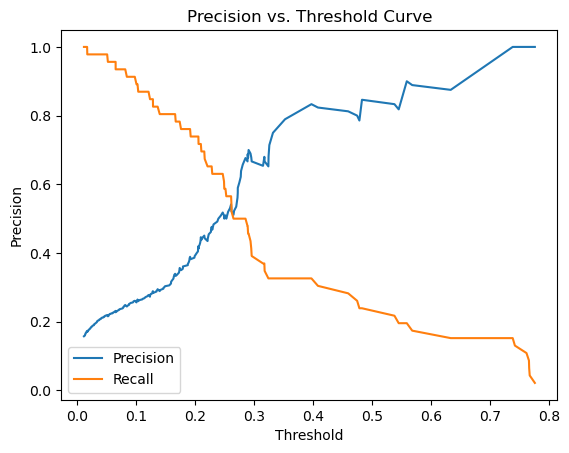

In [ ]:
fig,ax = plt.subplots()
ax.plot(thresholds, precision[:-1], label='Precision')
ax.plot(thresholds, recall[:-1], label='Recall')
ax.set_xlabel('Threshold')
ax.set_ylabel('Precision')
ax.set_title('Precision vs. Threshold Curve')
plt.legend()
plt.show()

For the model's predictions, we compute the threshold that corresponds to the best recall value

In [ ]:
# Get the threshold corresponding to the best recall
optimal_threshold_lstm = thresholds[np.where(precision==recall)[0]]
optimal_threshold_lstm[0]

0.26168573

Model's Accuracy, Precision and F1 Score on the test set:

In [ ]:
y_test_pred_lstm2 = (y_test_pred_lstm>=optimal_threshold_lstm).astype('int')
accuracy_score(y_test_,y_test_pred_lstm2)

0.8493150684931506

In [ ]:
# compute the test set precision based on the optimal threshold
precision_score(y_test_,y_test_pred_lstm2)

0.5217391304347826

In [ ]:
# compute the test set F1Score based on the optimal threshold
f1_score(y_test_,y_test_pred_lstm2)

0.5217391304347826

#### 3.4.2 Bidirectional LSTM

Experiment: Changing the model's default LSTM cells to bidirectional LSTM cells and observing the performance changes:

In [ ]:
articles_input = tf.keras.layers.Input(shape=(),dtype=tf.string)
queries_input = tf.keras.layers.Input(shape=(),dtype=tf.string)


article_tokens = text_vec_layer_articles(articles_input)
query_tokens = text_vec_layer_queries(queries_input)

articles_embedded = tf.keras.layers.Embedding(input_dim=articles_vocab_size,output_dim=100,
                             embeddings_initializer=tf.keras.initializers.Constant(articles_embedding_matrix),trainable=True,mask_zero=True)(article_tokens)
queries_embedded = tf.keras.layers.Embedding(input_dim=queries_vocab_size,output_dim=100,
                                       embeddings_initializer=tf.keras.initializers.Constant(queries_embedding_matrix),trainable=True,mask_zero=True)(query_tokens)

# concatenate the embeddings and remove the extra dimensions
distance=Lambda(euclidean_distance)([articles_embedded,queries_embedded])

# add an LSTM layer
lstm1 = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128,return_sequences=True,dropout=0.6))(distance)
lstm2 = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64,dropout=0.4))(lstm1)

# add a single output layer
out = tf.keras.layers.Dense(1,activation="sigmoid")(lstm2)

model_bidirectional = tf.keras.Model(inputs=[articles_input,queries_input],outputs=[out])

opt = tf.keras.optimizers.Adam(learning_rate=0.001)
precision_ = tf.keras.metrics.Precision()

# the early stopping callback to stop training if the validation loss doesn't improve
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=10, restore_best_weights=True)
# the reduce learning rate on plateau callback to lower the learning rate once it 'plateaus' i.e. is not improving
lrp_reducer = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=6, verbose=1)

model_bidirectional.compile(loss='binary_crossentropy',optimizer=opt,
              metrics=['accuracy',precision_])

history_bidirectional = model_bidirectional.fit((x_train_articles,x_train_queries),y_train_,validation_data=((x_valid_articles,x_valid_queries),y_valid_),
                    epochs=60,batch_size=256,verbose=0,callbacks=[early_stopping,lrp_reducer])

We compute the threshold that corresponds to the best F1 score - since F1 maximizes both precision and recall

In [ ]:
# Get the threshold corresponding to the maximum F1 Score
optimal_threshold_bidirectional = thresholds[np.where(precision==recall)[0]]
optimal_threshold_bidirectional[0]

0.26168573

F1 Score and Precision on the holdout test set

In [ ]:
y_test_pred_bidrectional = model_bidirectional.predict((x_test_articles,x_test_queries))
y_test_pred_bidrectional2 = (y_test_pred_bidrectional>=optimal_threshold_bidirectional).astype('int')

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step


In [ ]:
# compute the test set F1Score based on the optimal threshold
f1_score(y_test_,y_test_pred_bidrectional2)

0.5684210526315789

In [ ]:
# compute the test set precision based on the optimal threshold
precision_score(y_test_,y_test_pred_bidrectional2)

0.5510204081632653

#### 3.4.3 LSTM with GRU

Experiment: We experiment the changes in performance when we replace LSTM cells with GRU cells

In [ ]:
articles_input = tf.keras.layers.Input(shape=(),dtype=tf.string)
queries_input = tf.keras.layers.Input(shape=(),dtype=tf.string)


article_tokens = text_vec_layer_articles(articles_input)
query_tokens = text_vec_layer_queries(queries_input)

articles_embedded = tf.keras.layers.Embedding(input_dim=articles_vocab_size,output_dim=100,
                             embeddings_initializer=tf.keras.initializers.Constant(articles_embedding_matrix),trainable=True,mask_zero=True)(article_tokens)
queries_embedded = tf.keras.layers.Embedding(input_dim=queries_vocab_size,output_dim=100,
                                       embeddings_initializer=tf.keras.initializers.Constant(queries_embedding_matrix),trainable=True,mask_zero=True)(query_tokens)

# concatenate the embeddings and remove the extra dimensions
distance=Lambda(euclidean_distance)([articles_embedded,queries_embedded])

# add a GRU layer
gru1 = tf.keras.layers.GRU(128,return_sequences=True,dropout=0.6)(distance)
gru2 = tf.keras.layers.GRU(64,dropout=0.4)(gru1)

# add a single output layer
out = tf.keras.layers.Dense(1,activation="sigmoid")(gru2)

model_gru = tf.keras.Model(inputs=[articles_input,queries_input],outputs=[out])

opt = tf.keras.optimizers.Adam(learning_rate=0.001)

precision__ = tf.keras.metrics.Precision()

# the early stopping callback to stop training if the validation loss doesn't improve
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=10, restore_best_weights=True)
# the reduce learning rate on plateau callback to lower the learning rate once it 'plateaus' i.e. is not improving
lrp_reducer = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=6, verbose=1)


model_gru.compile(loss='binary_crossentropy',optimizer=opt,
              metrics=['accuracy',precision__])

history_gru = model_gru.fit((x_train_articles,x_train_queries),y_train_,validation_data=((x_valid_articles,x_valid_queries),y_valid_),
                    epochs=60,batch_size=256,verbose=0,callbacks=[early_stopping,lrp_reducer])

Get the threshold value that corresponds to the best F1 score:

In [ ]:
# Get the threshold corresponding to the maximum F1 score
optimal_threshold_gru = thresholds[np.where(precision==recall)[0]]
optimal_threshold_gru[0]

0.26168573

Compute the F1 and precision scores on the holdout testset

In [ ]:
y_test_pred_gru = model_gru.predict((x_test_articles,x_test_queries))
y_test_pred_gru2 = (y_test_pred_gru>=optimal_threshold_gru).astype('int')

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step


In [ ]:
# compute the test set F1Score based on the optimal threshold
f1_score(y_test_,y_test_pred_gru2)

0.5333333333333333

In [ ]:
# compute the test set precision based on the optimal threshold
precision_score(y_test_,y_test_pred_gru2)

0.6896551724137931

### Complex Model 2: Using a WaveNet - like based CNN model for the Task

#### 3.4.4 CNN Model - Preprocessing

Before training the complex model, data was tokenized into integers using the Keras text vectorisation layer, setting max tokens to 2000 and sequence length to 1000. This expansion from the previous limit of 1000 tokens and 500 sequence length for LSTM models was enabled by convnets' superior ability to handle and store multi-dimensional features.

In [ ]:
text_vec_layer_articles = tf.keras.layers.TextVectorization(max_tokens=2000,output_sequence_length=1000)
text_vec_layer_queries = tf.keras.layers.TextVectorization(max_tokens=2000,output_sequence_length=1000)

Adapting the text vectorization layers to the training data:

In [ ]:
x_train_articles = list(x_train['article'].values)

In [ ]:
text_vec_layer_articles.adapt(x_train_articles)

In [ ]:
x_train_queries = list(x_train['query'].values)

In [ ]:
text_vec_layer_queries.adapt(x_train_queries)

Converting the training articles and queries data into an appropriate format for the model.

In [ ]:
x_valid_queries = list(x_valid['query'].values)
x_valid_articles = list(x_valid['article'].values)
x_test_queries = list(x_test['query'].values)
x_test_articles = list(x_test['article'].values)

Building the vocabulary:

In [ ]:
articles_vocabulary = text_vec_layer_articles.get_vocabulary()
articles_wordindex = {word:index for index,word in enumerate(articles_vocabulary)}

In [ ]:
queries_vocabulary = text_vec_layer_queries.get_vocabulary()
queries_wordindex = {word:index for index,word in enumerate(queries_vocabulary)}

In [ ]:
# load pretrained embeddings into memory
embeddings_index = dict()

For this phase, 300-dimensional GloVe embeddings were loaded as pretrained embeddings. The selection of a higher-dimensional vector set was driven by the absence of memory constraints previously encountered with LSTM models. Additionally, the inherent capability of CNNs to efficiently extract features from high-dimensional data further justified this choice.

In [ ]:
with open('glove.6B.300d.txt', 'r',encoding="utf8") as file:
    for line in file:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:],dtype=np.float32)
        embeddings_index[word] = coefs

We then map the embedding vectors in this read file to the different words in our vocabulary:

In [ ]:
articles_vocab_size = len(articles_wordindex)
articles_embedding_matrix = np.zeros((articles_vocab_size,300))

for word,i in articles_wordindex.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        articles_embedding_matrix[i] = embedding_vector

In [ ]:
queries_vocab_size = len(queries_wordindex)
queries_embedding_matrix = np.zeros((queries_vocab_size,300))

for word,i in queries_wordindex.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        queries_embedding_matrix[i] = embedding_vector

Checking the size of our embedding vector matrices for our dataset:

In [ ]:
queries_embedding_matrix.shape,articles_embedding_matrix.shape

((300, 300), (2000, 300))

We then define a function to compute Euclidean distance:

In [ ]:
# define a function to compute the Euclidean distance
def euclidean_distance(vectors):
	# unpack the vectors into separate lists
	(featsA, featsB) = vectors
	# compute the sum of squared distances between the vectors
	sumSquared = K.sum(K.square(featsA - featsB), axis=1,
		keepdims=True)
	# return the euclidean distance between the vectors
	return K.sqrt(K.maximum(sumSquared, K.epsilon()))

#### 3.4.5 Complex Convolution Neural Networks Model - Config 1
- Using WaveNet based CNN architecture - with 2 stacks of convnets and the dilation doubled from 1 to 8. (It is key to note that we still maintain the siamese based approach for this task)

In [ ]:
# define our 2 model inputs - article text and user query text
articles_input = tf.keras.layers.Input(shape=(),dtype=tf.string)
queries_input = tf.keras.layers.Input(shape=(),dtype=tf.string)

# tokenize and vectorize using the text vectorization layer
article_tokens = text_vec_layer_articles(articles_input)
query_tokens = text_vec_layer_queries(queries_input)

# compute embeddings using GloVe embeddings - we use 300-dimensional GloVe embeddings for this step and
# set the initial layer weights to our earlier preprocessed and computed layer weights.
# set trainable to True to finetune the glove embeddings
articles_embedded = tf.keras.layers.Embedding(input_dim=articles_vocab_size,output_dim=300,
                             embeddings_initializer=tf.keras.initializers.Constant(articles_embedding_matrix),trainable=True,mask_zero=True)(article_tokens)
queries_embedded = tf.keras.layers.Embedding(input_dim=queries_vocab_size,output_dim=300,
                                       embeddings_initializer=tf.keras.initializers.Constant(queries_embedding_matrix),trainable=True,mask_zero=True)(query_tokens)


# hold the computed embeddings in these 2
x1 = articles_embedded
x2 = queries_embedded

# Apply the wavenet - based architecture to the articles embeddings with dilation ranging from 1 to 8.
for dilation_rate in (1, 2, 4, 8) * 2:
    x1 = tf.keras.layers.Conv1D(
                filters=32, kernel_size=2, padding="causal", activation="relu",
                dilation_rate=dilation_rate)(x1)
x1 = tf.keras.layers.Conv1D(filters=14, kernel_size=1)(x1)

# Apply the wavent based architecture to the queries embeddings with the dilation ranging from 1 to 8
# Causal padding was also applied so as to ensure the convnets output are of the same shape as the input with zeros padded at the start
for dilation_rate in (1, 2, 4, 8) * 2:
    x2 = tf.keras.layers.Conv1D(
                filters=32, kernel_size=2, padding="causal", activation="relu",
                dilation_rate=dilation_rate)(x2)
x2 = tf.keras.layers.Conv1D(filters=14, kernel_size=1)(x2)

# compute the Euclidean distance between the 2 CNN output vectors from the wavenet architectures
distance=Lambda(euclidean_distance)([x1,x2])

# flatten the output
flatten_ = tf.keras.layers.Flatten()(distance)

# add a single output layer
out = tf.keras.layers.Dense(1,activation="sigmoid")(flatten_)

model_cnn1 = tf.keras.Model(inputs=[articles_input,queries_input],outputs=[out])

In [ ]:
model_cnn1.summary()

Model: "functional_345"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_56      │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_57      │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization… │ (None, 1000)      │          0 │ input_layer_56[0… │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization… │ (None, 1000)      │          0 │ input_layer_57[0… │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_12        │ (None, 1000, 300) │    600,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_13        │ (None, 1000, 300) │     90,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_18 (Conv1D)  │ (None, 1000, 32)  │     19,232 │ embedding_12[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_27 (Conv1D)  │ (None, 1000, 32)  │     19,232 │ embedding_13[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_19 (Conv1D)  │ (None, 1000, 32)  │      2,080 │ conv1d_18[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_28 (Conv1D)  │ (None, 1000, 32)  │      2,080 │ conv1d_27[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_20 (Conv1D)  │ (None, 1000, 32)  │      2,080 │ conv1d_19[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_29 (Conv1D)  │ (None, 1000, 32)  │      2,080 │ conv1d_28[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_21 (Conv1D)  │ (None, 1000, 32)  │      2,080 │ conv1d_20[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_30 (Conv1D)  │ (None, 1000, 32)  │      2,080 │ conv1d_29[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_22 (Conv1D)  │ (None, 1000, 32)  │      2,080 │ conv1d_21[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_31 (Conv1D)  │ (None, 1000, 32)  │      2,080 │ conv1d_30[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_23 (Conv1D)  │ (None, 1000, 32)  │      2,080 │ conv1d_22[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_32 (Conv1D)  │ (None, 1000, 32)  │      2,080 │ conv1d_31[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_24 (Conv1D)  │ (None, 1000, 32)  │      2,080 │ conv1d_23[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_33 (Conv1D)  │ (None, 1000, 32)  │      2,080 │ conv1d_32[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_25 (Conv1D)  │ (None, 1000, 32)  │      2,080 │ conv1d_24[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_34 (Conv1D)  │ (None, 1000, 32)  │      2,080 │ conv1d_33[0][0] 

 Total params: 758,523 (2.89 MB)

 Trainable params: 758,523 (2.89 MB)

 Non-trainable params: 0 (0.00 B)

We now convert our data to an appropriate format expected by our tensorflow model:

In [ ]:
x_train_articles = tf.constant(x_train_articles,dtype=tf.string)
x_train_queries = tf.constant(x_train_queries,dtype=tf.string)
x_valid_articles = tf.constant(x_valid_articles,dtype=tf.string)
x_valid_queries = tf.constant(x_valid_queries,dtype=tf.string)
x_test_queries = tf.constant(x_test_queries,dtype=tf.string)
x_test_articles = tf.constant(x_test_articles,dtype=tf.string)

Defining a precision metric for evaluation:

In [ ]:
precision = tf.keras.metrics.Precision(name='precision')
f1 = tf.keras.metrics.F1Score(name='f1')

**Note** We made use of 2 callback functions:
- Early stopping and the Learning Rate Reducer on plateau - early stopping so as to stop training when there isn't an improvement in the validation loss and the LRP Reducer to keep lowering the learning rate by a factor of 0.1 when the loss 'plateaus'.

In [ ]:
# the early stopping callback to stop training if the validation loss doesn't improve
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=10, restore_best_weights=True)
# the reduce learning rate on plateau callback to lower the learning rate once it 'plateaus' i.e. is not improving
lrp_reducer = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=6, verbose=1)

In [ ]:
opt = tf.keras.optimizers.Adam(learning_rate=0.001)
model_cnn1.compile(loss='binary_crossentropy',optimizer=opt,
              metrics=['accuracy',precision])

In [ ]:
history_cnn1 = model_cnn1.fit((x_train_articles,x_train_queries),y_train_,validation_data=((x_valid_articles,x_valid_queries),y_valid_),
                    epochs=100,batch_size=256,callbacks=[early_stopping,lrp_reducer])

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 65s 796ms/step - accuracy: 0.8397 - loss: 0.4450 - precision: 0.0000e+00 - val_accuracy: 0.8418 - val_loss: 0.4105 - val_precision: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 66s 888ms/step - accuracy: 0.8397 - loss: 0.4029 - precision: 0.0000e+00 - val_accuracy: 0.8418 - val_loss: 0.4003 - val_precision: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 63s 835ms/step - accuracy: 0.8409 - loss: 0.3854 - precision: 0.6084 - val_accuracy: 0.8552 - val_loss: 0.3331 - val_precision: 0.5526 - learning_rate: 0.0010
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 64s 859ms/step - accuracy: 0.8639 - loss: 0.3295 - precision: 0.6683 - val_accuracy: 0.8721 - val_loss: 0.3065 - val_precision: 0.6154 - learning_rate: 0.0010
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 59s 790ms/step - accuracy: 0.8854 - loss: 0.2829 - precision: 0.7381 - val_accuracy: 0.8552 - val_loss: 0.3269 - val_precision: 0.5400 - learning_rate: 0

In [ ]:
history_cnn1.history.keys()

dict_keys(['accuracy', 'loss', 'precision', 'val_accuracy', 'val_loss', 'val_precision', 'learning_rate'])

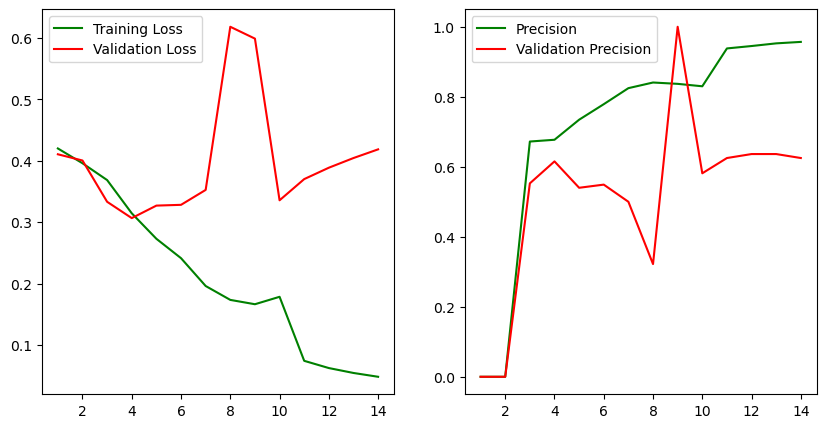

In [ ]:
epochs = np.arange(len(history_cnn1.history['loss']))+1

fig,ax = plt.subplots(1,2,figsize=(10,5))

ax[0].plot(epochs,history_cnn1.history['loss'],'g',label='Training Loss')
ax[0].plot(epochs,history_cnn1.history['val_loss'],'r',label='Validation Loss')
ax[0].legend()

ax[1].plot(epochs,history_cnn1.history['precision'],'g',label='Precision')
ax[1].plot(epochs,history_cnn1.history['val_precision'],'r',label='Validation Precision')
ax[1].legend()

#### 3.4.6 Complex Convolution Neural Networks Model - Config 2

Based on the observed training and validation curves, along with training logs, the model exhibited overfitting on the training set. An early stopping callback was implemented, successfully halting training and reverting to the best weights. Despite employing a Learning Rate Reducer callback, reducing the learning rate failed to address the overfitting issue. This led to the subsequent experiment, where the architecture was simplified by reducing the number of CNN layer stacks by one, to evaluate if a simpler network would enhance performance.

In [ ]:
# define our 2 model inputs - article text and user query text
articles_input = tf.keras.layers.Input(shape=(),dtype=tf.string)
queries_input = tf.keras.layers.Input(shape=(),dtype=tf.string)

# tokenize and vectorize using the text vectorization layer
article_tokens = text_vec_layer_articles(articles_input)
query_tokens = text_vec_layer_queries(queries_input)

# compute embeddings using GloVe embeddings - we use 300-dimensional GloVe embeddings for this step and
# set the initial layer weights to our earlier preprocessed and computed layer weights.
# set trainable to True to finetune the glove embeddings
articles_embedded = tf.keras.layers.Embedding(input_dim=articles_vocab_size,output_dim=300,
                             embeddings_initializer=tf.keras.initializers.Constant(articles_embedding_matrix),trainable=True,mask_zero=True)(article_tokens)
queries_embedded = tf.keras.layers.Embedding(input_dim=queries_vocab_size,output_dim=300,
                                       embeddings_initializer=tf.keras.initializers.Constant(queries_embedding_matrix),trainable=True,mask_zero=True)(query_tokens)


# hold the computed embeddings in these 2
x1 = articles_embedded
x2 = queries_embedded

# Apply the wavenet - based architecture to the articles embeddings with dilation ranging from 1 to 8.
for dilation_rate in (1, 2, 4, 8):
    x1 = tf.keras.layers.Conv1D(
                filters=32, kernel_size=2, padding="causal", activation="relu",
                dilation_rate=dilation_rate,
                kernel_regularizer=tf.keras.regularizers.L2(l2=0.001))(x1)
x1 = tf.keras.layers.Conv1D(filters=14, kernel_size=1,
                            kernel_regularizer=tf.keras.regularizers.L2(l2=0.001))(x1)

# Apply the wavent based architecture to the queries embeddings with the dilation ranging from 1 to 8
# Causal padding was also applied so as to ensure the convnets output are of the same shape as the input with zeros padded at the start
for dilation_rate in (1, 2, 4, 8):
    x2 = tf.keras.layers.Conv1D(
                filters=32, kernel_size=2, padding="causal", activation="relu",
                dilation_rate=dilation_rate,
                kernel_regularizer=tf.keras.regularizers.L2(l2=0.001))(x2)
x2 = tf.keras.layers.Conv1D(filters=14, kernel_size=1,
                            kernel_regularizer=tf.keras.regularizers.L2(l2=0.001))(x2)

# compute the Euclidean distance between the 2 CNN output vectors from the wavenet architectures
distance=Lambda(euclidean_distance)([x1,x2])

# flatten the output
flatten_ = tf.keras.layers.Flatten()(distance)

# add a single output layer
out = tf.keras.layers.Dense(1,activation="sigmoid")(flatten_)

model_cnn2 = tf.keras.Model(inputs=[articles_input,queries_input],outputs=[out])

In [ ]:
precision = tf.keras.metrics.Precision(name='precision_2')

In [ ]:
# the early stopping callback to stop training if the validation loss doesn't improve
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=10, restore_best_weights=True)
# the reduce learning rate on plateau callback to lower the learning rate once it 'plateaus' i.e. is not improving
lrp_reducer = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=6, verbose=1)

In [ ]:
opt = tf.keras.optimizers.Adam(learning_rate=0.001)
model_cnn2.compile(loss='binary_crossentropy',optimizer=opt,
              metrics=['accuracy',precision])

In [ ]:
history_cnn2 = model_cnn2.fit((x_train_articles,x_train_queries),y_train_,validation_data=((x_valid_articles,x_valid_queries),y_valid_),
                    epochs=100,batch_size=256,callbacks=[early_stopping,lrp_reducer])

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 56s 691ms/step - accuracy: 0.8297 - loss: 0.7825 - precision_2: 0.2569 - val_accuracy: 0.8418 - val_loss: 0.6313 - val_precision_2: 0.5000 - learning_rate: 0.0010
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 52s 692ms/step - accuracy: 0.8519 - loss: 0.6069 - precision_2: 0.6732 - val_accuracy: 0.8788 - val_loss: 0.5294 - val_precision_2: 0.8235 - learning_rate: 0.0010
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 50s 663ms/step - accuracy: 0.8718 - loss: 0.5198 - precision_2: 0.7248 - val_accuracy: 0.8822 - val_loss: 0.4953 - val_precision_2: 0.7308 - learning_rate: 0.0010
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 50s 662ms/step - accuracy: 0.8823 - loss: 0.4685 - precision_2: 0.7467 - val_accuracy: 0.8788 - val_loss: 0.4658 - val_precision_2: 0.6486 - learning_rate: 0.0010
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 56s 744ms/step - accuracy: 0.8902 - loss: 0.4364 - precision_2: 0.7584 - val_accuracy: 0.8788 - val_loss: 0.4442 - val_precision_2: 0.6571 - learning_rat

Compared to the previous model with 2 stacks of CNN layers - the network with one CNN layer had a higher validation loss. We now compare both models on the test set

Model 1 (Model with 2 stacks of dilated CNNs) Predictions on the test set:

In [ ]:
y_test_pred1 = model_cnn1.predict((x_test_articles,x_test_queries))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


Model 2 (Model with 1 stack of dilated CNNs) Predictions on the test set:

In [ ]:
y_test_pred2 = model_cnn2.predict((x_test_articles,x_test_queries))

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step


Determine the optimal threshold point for both models:

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test_, y_test_pred1)
model1_optimal_threshold = thresholds[np.where(precision==recall)[0]]
model1_optimal_threshold[0]

0.4229701

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test_, y_test_pred2)
model2_optimal_threshold = thresholds[np.where(precision==recall)[0]]
model2_optimal_threshold[0]

0.5073205

We need to optimize for both recall and precision - so we compare both models on the test set using the F1 score

Model 1 - (2 Stack Dilated CNN F1 score)

In [ ]:
y_test_pred_1 = (y_test_pred1>=model1_optimal_threshold).astype('int')
f1_score(y_test_,y_test_pred_1)

0.6521739130434783

Model 2 - (1 stack Dilated CNN F1 Score)

In [ ]:
y_test_pred_2 = (y_test_pred2>=model2_optimal_threshold).astype('int')
f1_score(y_test_,y_test_pred_2)

0.6739130434782609

## 4.0 Results

###  4.1 Baseline Machine Learning Models

In [ ]:
performance_results = {
'Logistic Regression': [log_precision, log_recall, best_log_f1],
'SVM': [svm_precision, svm_recall, best_svm_f1],
'Random Forest': [rf_precision, rf_recall, best_rf_f1],
'XGBoost': [xgb_precision, xgb_recall, best_xgb_f1],
'Naive Bayes': [nb_precision, nb_recall, best_nb_f1]
}

# Convert the dictionary into a pandas DataFrame
results_ML = pd.DataFrame.from_dict(performance_results, orient='index', columns=['Precision', 'Recall', 'F1 Score'])
results_ML = results_ML.round(2)

# Display the results as a table
print("Model Performance Comparison:")
results_ML

Model Performance Comparison:


,Precision,Recall,F1 Score
Logistic Regression,0.43,0.74,0.54
SVM,0.41,0.36,0.39
Random Forest,0.77,0.57,0.66
XGBoost,0.81,0.55,0.66
Naive Bayes,0.83,0.21,0.34


RandomForest and XGBoost generates the same result of 0.66 for F1 Score. Compared to Random Forest, XgBoost has better performance on precision score, suggesting that XGBoost model can correctly predict more relevance class. Thus, XGBoost will represent standard Machine Learning Model to compare with other advanced models in the last part.


###  4.2 3-Layer Neural Network

In [ ]:
results_shallowNN = pd.DataFrame(results_shallowNN)
results_shallowNN = results_shallowNN.round(2)
results_shallowNN

,Number of Neurons,Precision,Recall,F1 Score
0,8,0.47,0.70,0.56
1,16,0.47,0.70,0.56
2,32,0.49,0.72,0.58
3,64,0.50,0.77,0.61
4,128,0.49,0.72,0.58
5,256,0.50,0.70,0.58
6,512,0.53,0.68,0.60


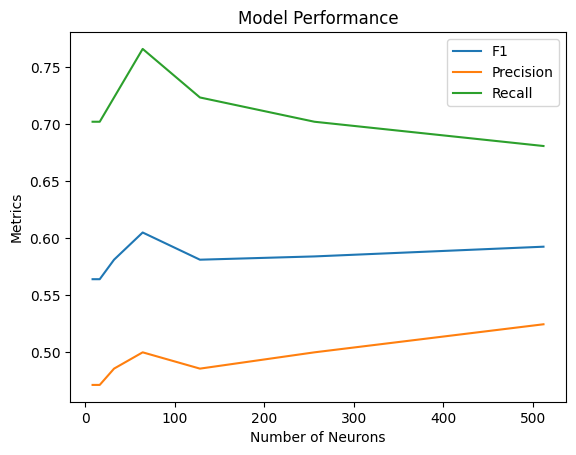

In [ ]:
# Plotting
plt.plot(num_neurons, f1_list, label='F1')
plt.plot(num_neurons, precision_list, label='Precision')
plt.plot(num_neurons, recall_list, label='Recall')

# Adding labels and title
plt.xlabel('Number of Neurons')
plt.ylabel('Metrics')
plt.title('Model Performance')

# Adding legend
plt.legend()

# Display plot
plt.show()

It can be seen from the result table that F1 Score do not change considerably as neuron number increases. 64 neurons gives the model highest F1 score. After 128 neurons, increasing number of neurons does not have huge impact on F1 Score and Recall.

###  4.3 Deep Neural Network

In [ ]:
results_deepNN = pd.DataFrame(results_deepNN)
results_deepNN = results_deepNN.round(2)
results_deepNN

,Activation,Number of Layers,Precision,Recall,F1 Score
0,relu,4,0.39,0.79,0.52
1,relu,5,0.35,0.77,0.48
2,relu,6,0.38,0.85,0.52
3,relu,7,0.36,0.83,0.50
4,relu,8,0.47,0.53,0.50
5,elu,4,0.39,0.70,0.50
6,elu,5,0.37,0.85,0.52
7,elu,6,0.31,0.81,0.45
8,elu,7,0.34,0.83,0.48
9,elu,8,0.48,0.55,0.51


The above DataFrame summarises the results from deep neural network model building with 35 configurations combined by different number of layers and various activations. Overall, the recall seems higher than the precision, but most combinations give the balance between these two scores. Model with 6 layers and using swish as activation function gives the highest F1 score.

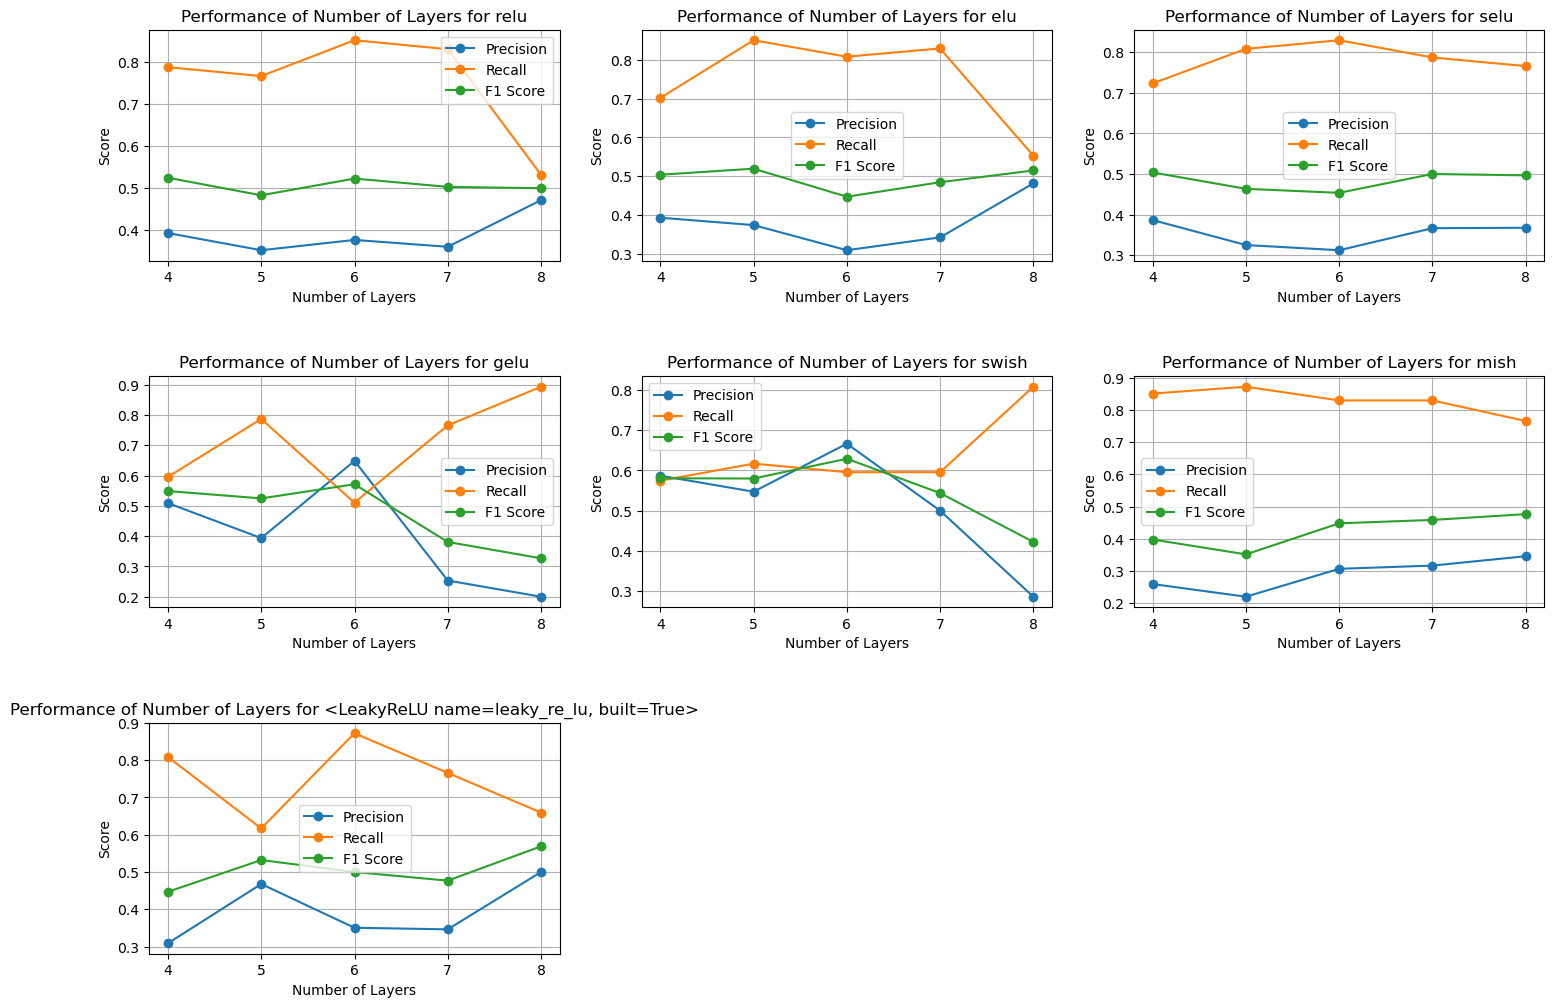

In [ ]:
import matplotlib.pyplot as plt
# Plotting
fig, axs = plt.subplots(3, 3, figsize=(18, 12))
fig.subplots_adjust(hspace=0.5)

for i, activation_name in enumerate(activations):
    ax = axs[i // 3, i % 3]
    ax.plot(layers, precision_scores[activation_name], marker='o', label='Precision')
    ax.plot(layers, recall_scores[activation_name], marker='o', label='Recall')
    ax.plot(layers, f1_scores[activation_name], marker='o', label='F1 Score')

    ax.set_title(f'Performance of Number of Layers for {activation_name}')
    ax.set_xlabel('Number of Layers')
    ax.set_ylabel('Score')
    ax.set_xticks(layers)
    ax.legend()
    ax.grid(True)

for ax in axs.flatten()[len(activations):]:
    ax.axis('off')

plt.show()

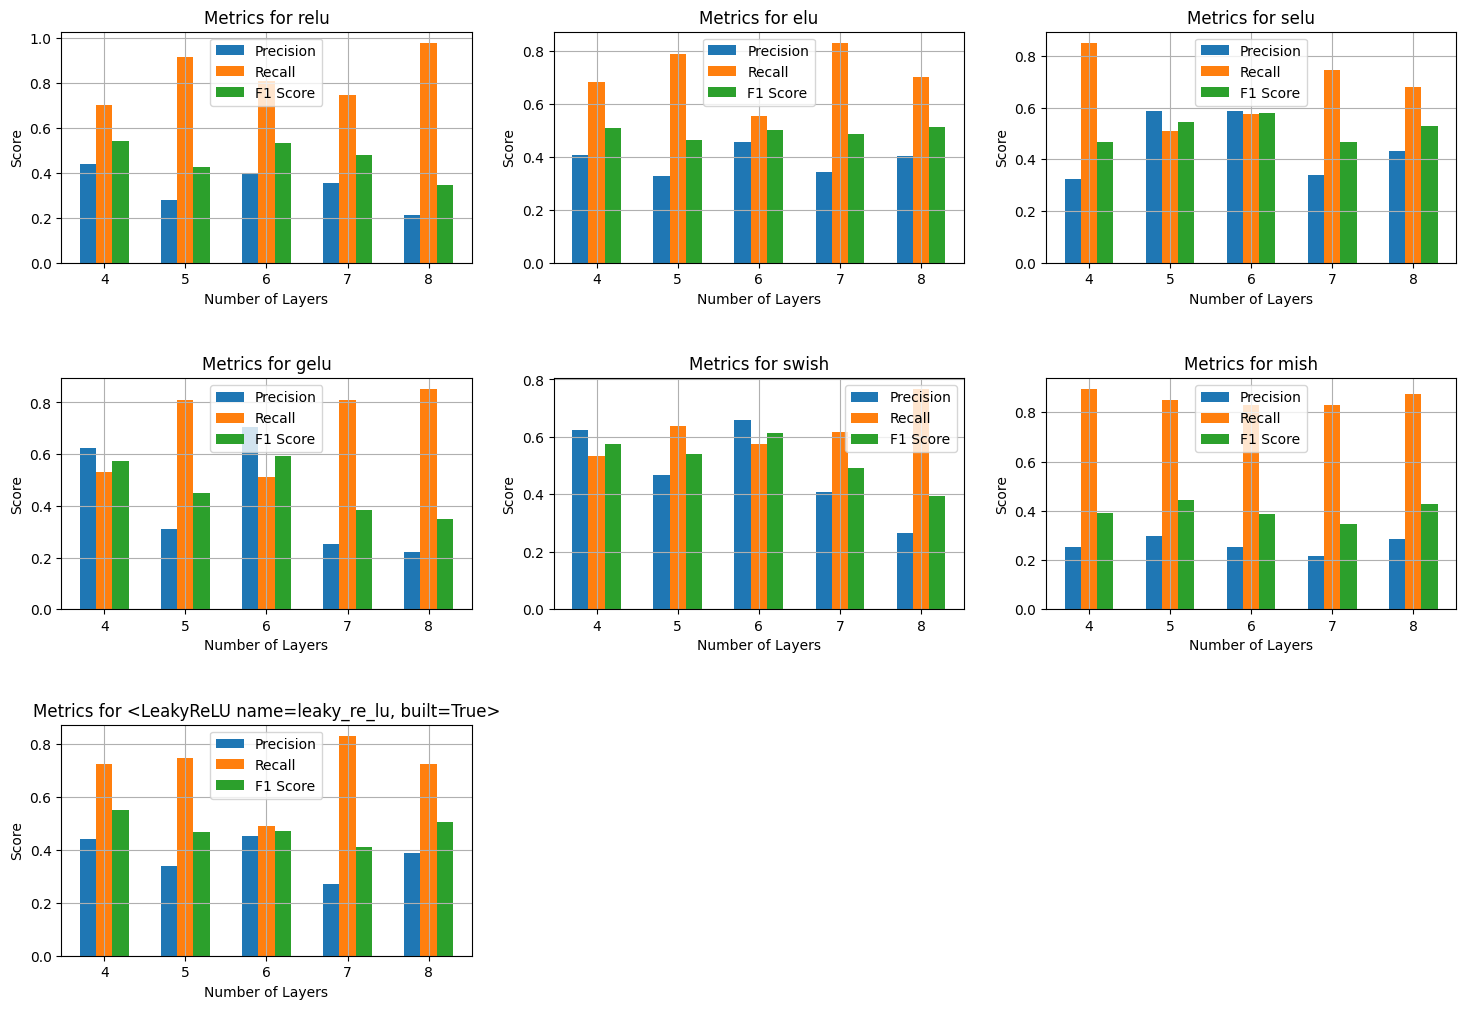

In [ ]:
# Plotting
fig, axs = plt.subplots(3, 3, figsize=(18, 12))
fig.subplots_adjust(hspace=0.5)

for i, activation_name in enumerate(activations):
    ax = axs[i // 3, i % 3]
    ax.bar(np.array(layers) - 0.2, precision_scores[activation_name], width=0.2, label='Precision')
    ax.bar(layers, recall_scores[activation_name], width=0.2, label='Recall')
    ax.bar(np.array(layers) + 0.2, f1_scores[activation_name], width=0.2, label='F1 Score')

    ax.set_title(f'Metrics for {activation_name}')
    ax.set_xlabel('Number of Layers')
    ax.set_ylabel('Score')
    ax.set_xticks(layers)
    ax.legend()
    ax.grid(True)

for ax in axs.flatten()[len(activations):]:
    ax.axis('off')
plt.show()

The graphs show that increasing number of layers does not pose substantial impact on F1 Score. Gelu and Swish generates high F1 Score over the number of layers, in which, Swish has better performance than Gelu. For Gelu and Swish, 6 layers gives the best result. Swish is also the most recommended activation if using deep model.
Selu and Mish is not suitable activations for this task. relu and elu indicates the same pattern with the previous two activations. Only at 8 layers, the model performance seems balance among three metrics but the score level is not quite high.

#####  4.4 Complex Models

#### 4.4.1 LSTM
The default LSTM model was compared to the bidirectional LSTM and the model with LSTMs replaced by GRU cells. As seen below, the bidirectional LSTM model attained a higher F1 score - our target metric which maximizes recall and precision.

In [ ]:
# Create a dataframe to store the results
results_df = pd.DataFrame({
    'Model': ['Bidirectional LSTM', 'LSTM', 'GRU'],
    'Precision': [precision_score(y_test_, y_test_pred_bidrectional2),
                  precision_score(y_test_, y_test_pred_lstm2),
                  precision_score(y_test_, y_test_pred_gru2)],
    'F1 Score':  [f1_score(y_test_, y_test_pred_bidrectional2),
                  f1_score(y_test_, y_test_pred_lstm2),
                  f1_score(y_test_, y_test_pred_gru2)]
})

# Find the best F1 score and corresponding model
best_f1_score = results_df['F1 Score'].max()
best_model = results_df.loc[results_df['F1 Score'].idxmax(), 'Model']

# Print the best F1 score and corresponding model
print("Best F1 Score:", best_f1_score)
print("Best Model:", best_model)

#
print("\nResults DataFrame:")
results_df = results_df.round(2)
results_df

Best F1 Score: 0.5684210526315789
Best Model: Bidirectional LSTM

Results DataFrame:


,Model,Precision,F1 Score
0,Bidirectional LSTM,0.55,0.57
1,LSTM,0.52,0.52
2,GRU,0.69,0.53


Graphs to compare model performance and the 2 experiments:

**Loss functions**

In [ ]:
train_loss = history_lstm.history['loss']
bidirectional_train_loss = history_bidirectional.history['loss']
gru_train_loss = history_gru.history['loss']

val_loss = history_lstm.history['val_loss']
bidirectional_val_loss = history_bidirectional.history['val_loss']
gru_val_loss = history_gru.history['val_loss']

epochs = range(1, len(train_loss) + 1)

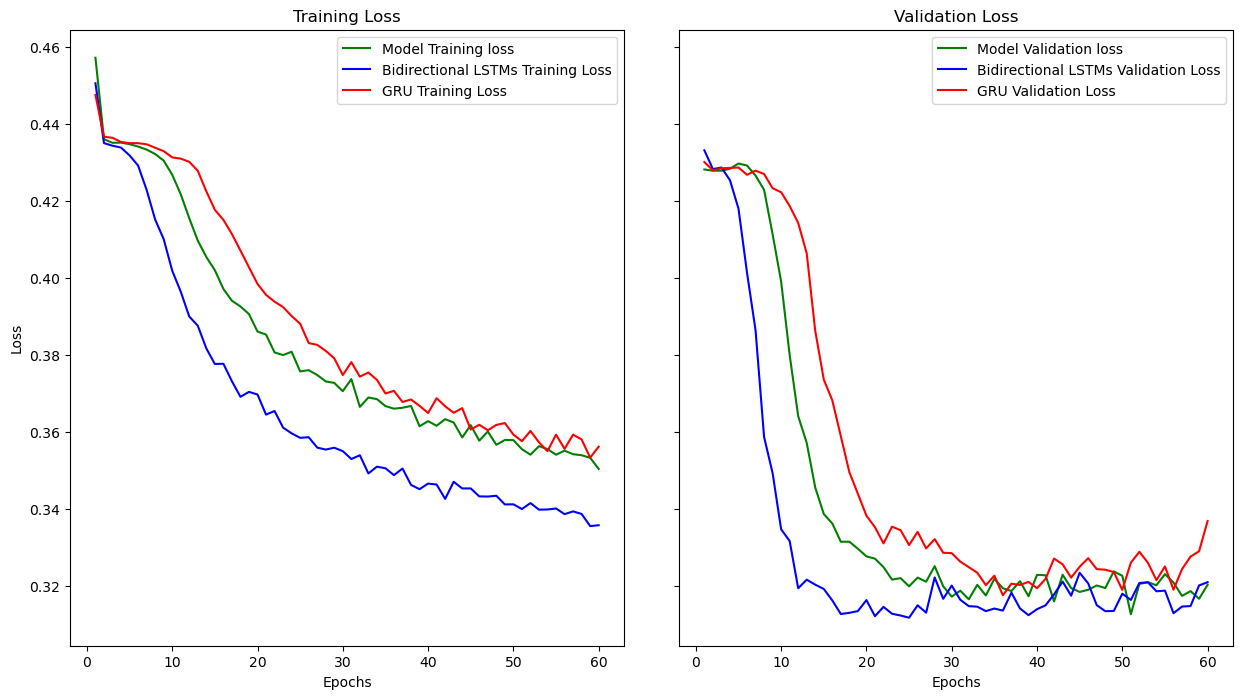

In [ ]:
fig,ax=plt.subplots(1,2,figsize=(15,8),sharey=True)
plt.subplots_adjust(wspace=0.1)
ax[0].plot(epochs,train_loss,'g',label='Model Training loss')
ax[0].plot(epochs,bidirectional_train_loss,'b',label='Bidirectional LSTMs Training Loss')
ax[0].plot(epochs,gru_train_loss,'r',label='GRU Training Loss')
ax[0].set_title('Training Loss')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()

ax[1].plot(epochs,val_loss,'g',label='Model Validation loss')
ax[1].plot(epochs,bidirectional_val_loss,'b',label='Bidirectional LSTMs Validation Loss')
ax[1].plot(epochs,gru_val_loss,'r',label='GRU Validation Loss')
ax[1].set_xlabel('Epochs')
ax[1].set_title('Validation Loss')
ax[1].legend()


**Precision:**

In [ ]:
train_precision = history_lstm.history['precison']
bidirectional_train_precision = history_bidirectional.history['precision_1']
gru_train_precision = history_gru.history['precision_3']

val_precision = history_lstm.history['val_precison']
bidirectional_val_precision = history_bidirectional.history['val_precision_1']
gru_val_precision = history_gru.history['val_precision_3']

epochs = range(1, len(train_loss) + 1)

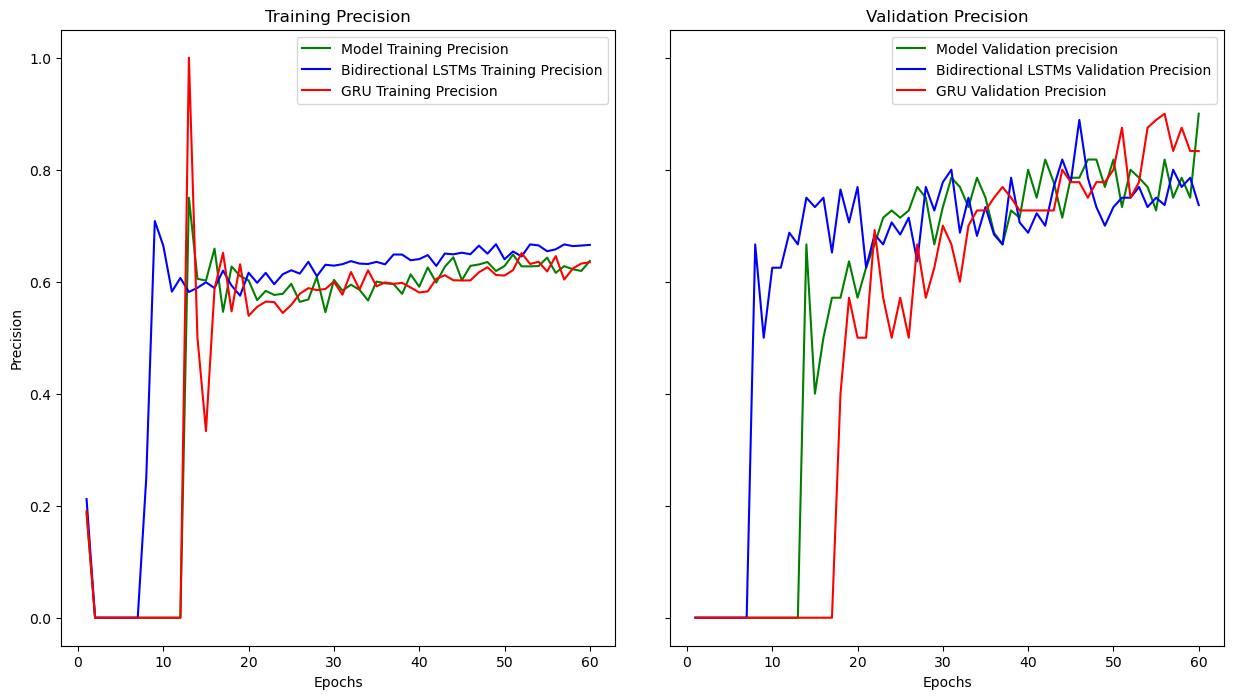

In [ ]:
fig,ax=plt.subplots(1,2,figsize=(15,8),sharey=True)
plt.subplots_adjust(wspace=0.1)
ax[0].plot(epochs,train_precision,'g',label='Model Training Precision')
ax[0].plot(epochs,bidirectional_train_precision,'b',label='Bidirectional LSTMs Training Precision')
ax[0].plot(epochs,gru_train_precision,'r',label='GRU Training Precision')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Precision')
ax[0].set_title('Training Precision')
ax[0].legend()

ax[1].plot(epochs,val_precision,'g',label='Model Validation precision')
ax[1].plot(epochs,bidirectional_val_precision,'b',label='Bidirectional LSTMs Validation Precision')
ax[1].plot(epochs,gru_val_precision,'r',label='GRU Validation Precision')
ax[1].set_xlabel('Epochs')
ax[1].set_title('Validation Precision')
ax[1].legend()

**Accuracy:**

In [ ]:
train_accuracy = history_lstm.history['accuracy']
bidirectional_train_accuracy = history_bidirectional.history['accuracy']
gru_train_accuracy = history_gru.history['accuracy']

val_accuracy = history_lstm.history['val_accuracy']
bidirectional_val_accuracy = history_bidirectional.history['val_accuracy']
gru_val_accuracy = history_gru.history['val_accuracy']

epochs = range(1, len(train_loss) + 1)

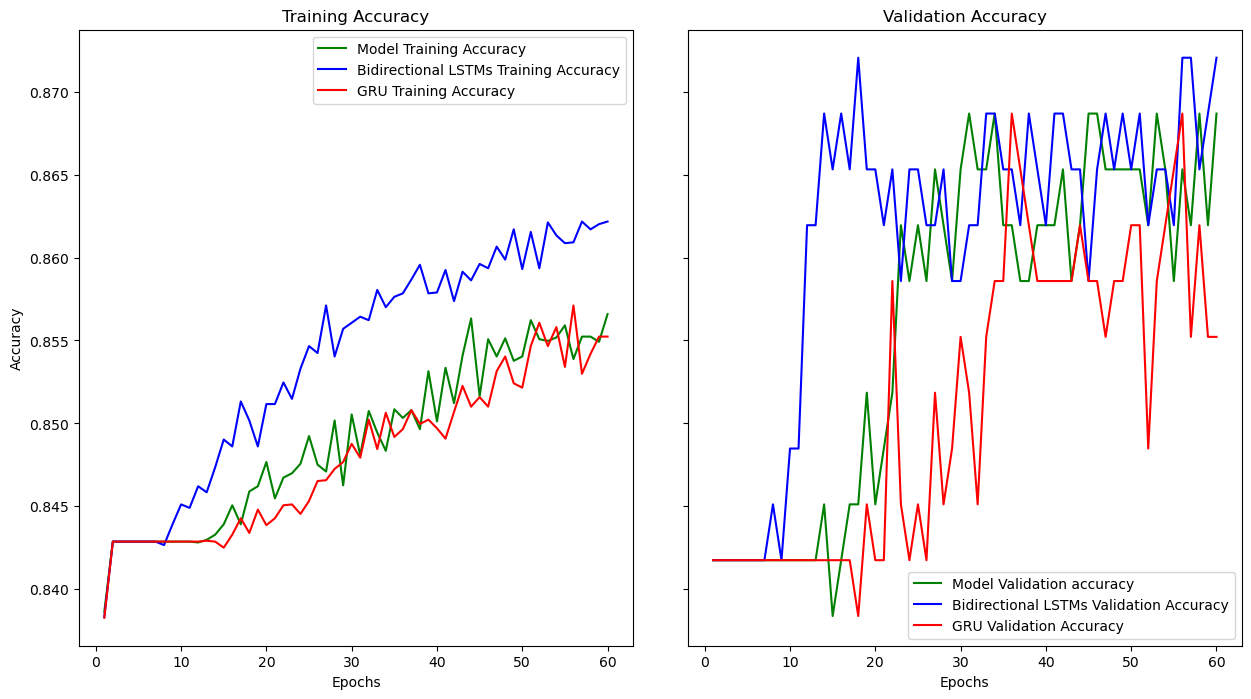

In [ ]:
fig,ax=plt.subplots(1,2,figsize=(15,8),sharey=True)
plt.subplots_adjust(wspace=0.1)
ax[0].plot(epochs,train_accuracy,'g',label='Model Training Accuracy')
ax[0].plot(epochs,bidirectional_train_accuracy,'b',label='Bidirectional LSTMs Training Accuracy')
ax[0].plot(epochs,gru_train_accuracy,'r',label='GRU Training Accuracy')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].set_title('Training Accuracy')
ax[0].legend()

ax[1].plot(epochs,val_accuracy,'g',label='Model Validation accuracy')
ax[1].plot(epochs,bidirectional_val_accuracy,'b',label='Bidirectional LSTMs Validation Accuracy')
ax[1].plot(epochs,gru_val_accuracy,'r',label='GRU Validation Accuracy')
ax[1].set_xlabel('Epochs')
ax[1].set_title('Validation Accuracy')
ax[1].legend()

**Much as the bidirectional LSTM seemed to have better performance (accuracy, precision, loss and F1 score) than the default LSTM model and the GRU model as seen in the above graphs, both the model with GRUs and the default model outperformed the Bidirectional LSTM model on the Kaggle dataset - achieving a score 0f 0.87305 compared to the bidirectional LSTM score of 0.87278. However our metric of evaluation as a group is F1 score since it maximizes both the precision and recall values, hence despite the Kaggle scores - the Bidirectional LSTM performed better than its 2 counterparts in terms of maximizing both precision and recall.**

#### 4.4.2 CNN

##### CNN Model 1  - 2 stack wavenet based CNN architecture

The CNN model with one stack of dilated CNNs produced a higher F1 score, but only  achieves a score of 77% on the kaggle test set, lower than the 2 stack CNN model. The metrics below summarise both CNN models

In [ ]:
# Create a dataframe to store the results
results_df = pd.DataFrame({
    'Model': ['CNN1', 'CNN2'],
    'Precision': [precision_score(y_test_, y_test_pred_bidrectional2),
                  precision_score(y_test_, y_test_pred_lstm2)],
    'F1 Score':  [f1_score(y_test_, y_test_pred_1),
                  f1_score(y_test_, y_test_pred_2)]
})

# Find the best F1 score and corresponding model
best_f1_score = results_df['F1 Score'].max()
best_model = results_df.loc[results_df['F1 Score'].idxmax(), 'Model']

# Print the best F1 score and corresponding model
print("Best F1 Score:", best_f1_score)
print("Best Model:", best_model)

# Optionally, you can also print the dataframe with all results
print("\nResults DataFrame:")
results_df = results_df.round(2)
results_df

Best F1 Score: 0.6739130434782609
Best Model: CNN2

Results DataFrame:


,Model,Precision,F1 Score
0,CNN1,0.55,0.65
1,CNN2,0.52,0.67


## **5.0 Summary**

To predict the relevance of article content with F1 Score as metric, five types of models, including basic Machine Learning and neural network models are employed. Five machine learning techniques are used to train the model, and XGBoost is the most suitable with Kaggle accuracy score of 87.223%. All models have been fine-tuned and tested on valid test to produce the model with the most favoreable result. The basic three-layer neural network is built with relu as activation and adam as optimizer. After that, the model is trained with different number of neurons and the result shows that 64 neurons gives the best performance (81.048 % of Kaggle accuracy score). The deep model training suggests that 6 layers with activation swish achieves highest F1 Score (87.196 % of Kaggle accuracy score). Two different complex models, namely LSTM and CNN are used and experimented with some configurations. The results indicate that Bidirectional LSTM and one stack dilated CNN are the most appropriate for this task with Kaggle accuracy score of 81.408% and 79.606% respectively. One stack dilated convolutional model is recommended for this task as it has highest F1 score.

To further improve the performance of the relevance classification, we will look at the use of transformer architecture models - which have achieved state of the art text classification performance on a number of image tasks. We also will look at the use of other state of the art models such as sentence encoder and decoder models - which we believe are capable of improving the model performance significantly.